# Replicating MMR Results - Linear DE

#### Setting up the Kernel


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

In [2]:
def build_HEA(n_qubits = 8, seed = 1):
    depth = 5
    rng = np.random.default_rng(seed = seed)
    theta = rng.uniform(0, 2 * np.pi, size = (depth, n_qubits, 2))
    
    qc = QuantumCircuit(n_qubits, name = "HEA")
    
    for i in range(depth):
        for q in range(n_qubits):
            qc.rx(theta[i, q, 0], q)
            qc.rz(theta[i, q, 1], q)
            
        for q in range(n_qubits - 1):
            qc.cx(q, q+1)
            
    return qc

def build_kernel_feature_map(n_qubits = 8):
    x = Parameter("x")
    qc = QuantumCircuit(n_qubits, name = "KernelMap")
    
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
        
    qc.compose(build_HEA(n_qubits), inplace = True)
    
    for q in range(n_qubits):
        qc.rx((q * x) / 2, q)
    
    return qc


N_QUBITS = 8
_QC = build_kernel_feature_map(N_QUBITS)
_PX = [p for p in _QC.parameters if p.name == "x"][0]

def _psi(x):
    qc = _QC.assign_parameters({_PX: x})
    return Statevector.from_instruction(qc).data


def kappa(u, v):
    return np.abs(np.vdot(_psi(v), _psi(u)))**2

print("Kernel ready. Ex. kappa(0.3,0.3) =", round(kappa(0.29, 0.31), 6))

Kernel ready. Ex. kappa(0.3,0.3) = 0.993113


In [3]:
import numpy as np
from scipy.optimize import minimize

class MMRSolver:
    def __init__(self, x_train, gamma=1e5):
        self.X = np.asarray(x_train, float)
        self.N = len(self.X)
        self.gamma = gamma  # optional regularization strength

    def _build_kernel_matrix(self, kernel):
        X = self.X
        return np.array([[kernel(X[i], X[j]) for j in range(self.N)]
                         for i in range(self.N)])

    def fit(self, kernel, y_train):
        X, N = self.X, self.N

        K = self._build_kernel_matrix(kernel)
        y_train = np.asarray(y_train, float)

        # parameters: alpha (N,) and bias b
        def f(params):
            alpha = params[:N]
            b = params[N]

            preds = K @ alpha + b
            err = preds - y_train

            # MSE loss (paper definition)
            loss = np.sum(err**2)

            # optional L2 regularization on alpha
            loss += (1.0 / self.gamma) * np.sum(alpha**2)
            return loss

        def grad(params):
            alpha = params[:N]
            b = params[N]

            preds = K @ alpha + b
            err = preds - y_train

            grad_alpha = 2 * (K.T @ err)
            grad_b = 2 * np.sum(err)

            grad_alpha += (2.0 / self.gamma) * alpha

            return np.concatenate([grad_alpha, [grad_b]])

        init = np.zeros(N + 1)

        res = minimize(f, init, jac=grad, method="Newton-CG")

        self.alpha = res.x[:N]
        self.b = res.x[N]

        print("MMR trained | success:", res.success)

        return self

    def predict(self, x_eval, kernel):
        X = self.X
        x_eval = np.atleast_1d(np.asarray(x_eval, float))

        preds = []
        for x in x_eval:
            kvec = np.array([kernel(X[j], x) for j in range(self.N)])
            preds.append(np.dot(self.alpha, kvec) + self.b)

        return np.array(preds)

In [12]:
# ============================================================
# LINEAR ODE:  f' + p(x) f + r(x) = 0
# ============================================================
LAMBDA_K = 0.2      # p(x) = lambda_k  (constant coefficient of f)
LAMBDA   = 20.0
X0, F0   = 0.0, 1.0

def p_coef(x):  return LAMBDA_K          # coefficient of f (constant)
def r_fun(x):   return LAMBDA * np.exp(-LAMBDA_K * x) * np.sin(LAMBDA * x)
def f_exact(x): return np.exp(-LAMBDA_K * x) * np.cos(LAMBDA * x)

print(f"ODE: f' = -{LAMBDA_K} f - {LAMBDA} exp(-{LAMBDA_K} x) sin({LAMBDA} x),  f(0)={F0}")
print(f"Analytic solution: f(x) = exp(-{LAMBDA_K} x) cos({LAMBDA} x)")

ODE: f' = -0.2 f - 20.0 exp(-0.2 x) sin(20.0 x),  f(0)=1.0
Analytic solution: f(x) = exp(-0.2 x) cos(20.0 x)


In [13]:
# ============================================================
# SOLVE  (paper setup: 21 points, gamma = 1e5)
# ============================================================
x_train = np.linspace(0, 1, 21)
x_test  = np.linspace(0, 1, 200)

y_train = f_exact(x_train)
y_test = f_exact(x_test)

solver = MMRSolver(x_train, gamma=1e5)

solver.fit(
    kernel=kappa,
    y_train=y_train
)

f_pred = solver.predict(x_test, kernel=kappa)

err = np.abs(f_pred - y_test)
rng = y_test.max() - y_test.min()

print(f"\nf_pred(0) = {f_pred[0]:.6f}  (target {y_test[0]:.6f})")
print(f"max abs error      = {err.max():.4e}")
print(f"mean abs error     = {err.mean():.4e}")
print(f"max normalized err = {err.max()/rng:.4e}")

MMR trained | success: False

f_pred(0) = 1.058790  (target 1.000000)
max abs error      = 2.6225e-01
mean abs error     = 9.3034e-02
max normalized err = 1.3319e-01


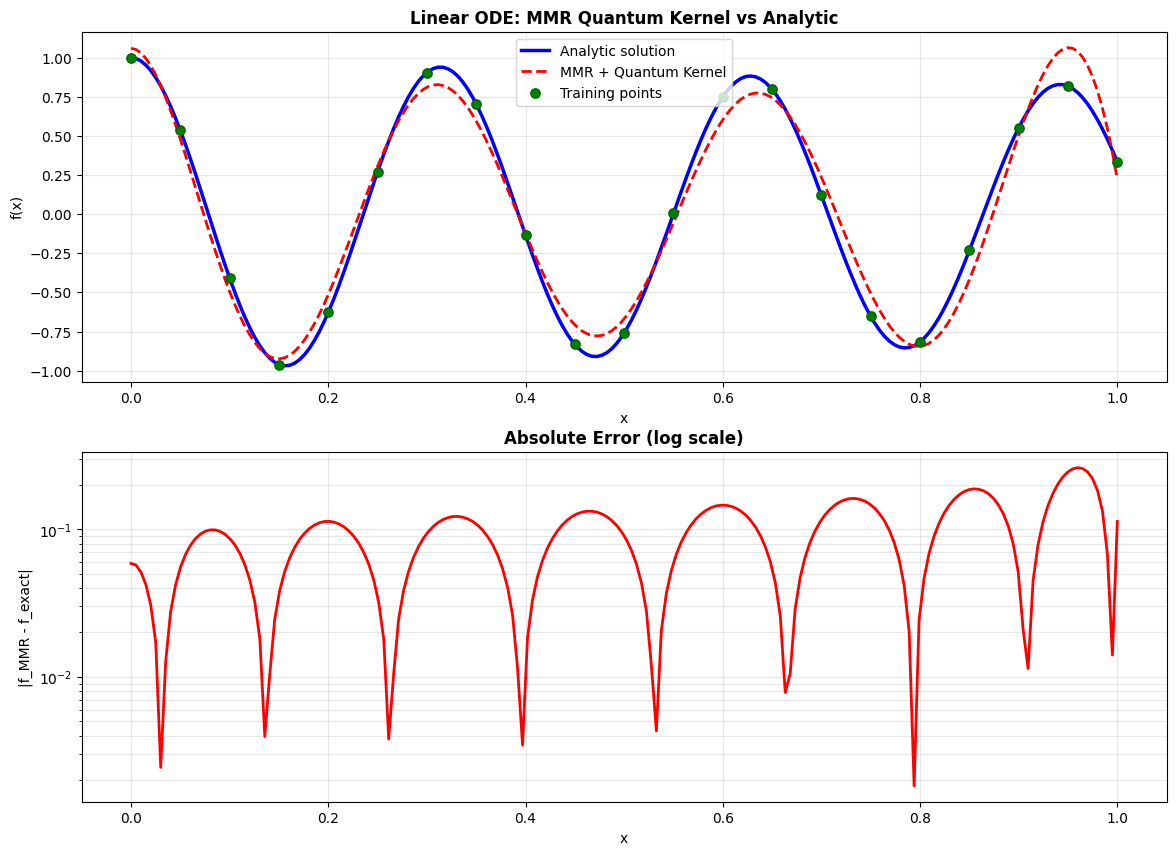

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# ------------------------------------------------------------
# (1) Function approximation
# ------------------------------------------------------------
ax[0].plot(x_test, y_test, "b-", lw=2.5, label="Analytic solution")
ax[0].plot(x_test, f_pred, "r--", lw=2, label="MMR + Quantum Kernel")

ax[0].scatter(
    x_train,
    y_train,
    color="green",
    s=45,
    zorder=5,
    edgecolors="darkgreen",
    label="Training points"
)

ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")
ax[0].set_title("Linear ODE: MMR Quantum Kernel vs Analytic", fontweight="bold")
ax[0].legend()
ax[0].grid(alpha=0.3)

# ------------------------------------------------------------
# (2) Absolute error
# ------------------------------------------------------------
ax[1].semilogy(x_test, err, "r-", lw=2)
ax[1].set_xlabel("x")
ax[1].set_ylabel("|f_MMR - f_exact|")
ax[1].set_title("Absolute Error (log scale)", fontweight="bold")
ax[1].grid(alpha=0.3, which="both")

In [16]:
# ============================================================
# SUMMARY
# ============================================================
print("="*64)
print("LINEAR ODE  -  FIRST-ORDER MMR (QUANTUM KERNEL)")
print("="*64)
print(f"Equation : f' = -{LAMBDA_K} f - {LAMBDA} exp(-{LAMBDA_K} x) sin({LAMBDA} x)")
print(f"IC       : f(0) = {F0}")
print(f"Kernel   : 2x(HEA depth-1 + feature map), {N_QUBITS} qubits")
print(f"Training : {len(x_train)} points, gamma = {solver.gamma:.0e}")
print("-"*64)
print(f"f_pred(0)            = {f_pred[0]:.6f}  (target {F0})")
print(f"max absolute error   = {err.max():.4e}")
print(f"mean absolute error  = {err.mean():.4e}")
print(f"max normalized error = {err.max()/rng:.4e}")
print(f"(paper Fig. 5 reports normalized error below ~2e-3)")
print("="*64)

LINEAR ODE  -  FIRST-ORDER MMR (QUANTUM KERNEL)
Equation : f' = -0.2 f - 20.0 exp(-0.2 x) sin(20.0 x)
IC       : f(0) = 1.0
Kernel   : 2x(HEA depth-1 + feature map), 8 qubits
Training : 21 points, gamma = 1e+05
----------------------------------------------------------------
f_pred(0)            = 1.058790  (target 1.0)
max absolute error   = 2.6225e-01
mean absolute error  = 9.3034e-02
max normalized error = 1.3319e-01
(paper Fig. 5 reports normalized error below ~2e-3)
